In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -1. loading data
df = pd.read_csv("./my_transcriptome_data/gene_fpkm.csv")
print("data shape:", df.shape)
display(df.head())

data shape: (123202, 20)


,gene_id,R2,CR3,R3,CR2,CT1,CO2,CO3,CT2,CR1,R1,CT3,CO1,NR Description,NT Description,Swissprot Description,PFAM description,BP Description,MF Description,CC Description
0,Cluster-14358.59966,0.00,0.00,0.00,0.00,0.87,0.51,0.88,0.00,0.00,0.00,1.89,1.80,zinc finger MYM-type protein 1-like [Dendrobiu...,--,--,--,--,--,--
1,Cluster-1252.0,0.00,0.00,0.00,0.00,0.00,4.23,0.00,0.00,0.00,0.00,0.00,0.00,uncharacterized protein LOC110101440 [Dendrobi...,--,--,--,--,--,--
2,Cluster-32411.0,563.42,53.61,851.04,32.71,5.22,12.06,15.18,29.85,7.19,732.51,22.15,13.35,"chlorophyll a-b binding protein 37, chloroplas...",Panax ginseng chlorophyll a/b-binding protein ...,"Chlorophyll a-b binding protein 37, chloroplas...",--,--,--,--
3,Cluster-14358.55088,0.14,0.00,0.03,0.27,1.32,0.06,1.53,0.27,3.70,0.00,0.90,4.24,"protoporphyrinogen oxidase, mitochondrial-like...",PREDICTED: Phalaenopsis equestris protoporphyr...,Protoporphyrinogen oxidase 2 OS=Spinacia olera...,Flavin containing amine oxidoreductase,oxidation-reduction process,oxidoreductase activity,--
4,Cluster-18277.0,0.00,0.00,0.00,0.00,0.00,0.00,2.52,0.00,0.73,0.00,0.00,0.00,--,--,--,--,--,--,--


In [2]:
# 2. 基本信息
print("data shape:", df.shape)
print("\nthe first five lines:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

data shape: (123202, 20)

the first five lines:


,gene_id,R2,CR3,R3,CR2,CT1,CO2,CO3,CT2,CR1,R1,CT3,CO1,NR Description,NT Description,Swissprot Description,PFAM description,BP Description,MF Description,CC Description
0,Cluster-14358.59966,0.00,0.00,0.00,0.00,0.87,0.51,0.88,0.00,0.00,0.00,1.89,1.80,zinc finger MYM-type protein 1-like [Dendrobiu...,--,--,--,--,--,--
1,Cluster-1252.0,0.00,0.00,0.00,0.00,0.00,4.23,0.00,0.00,0.00,0.00,0.00,0.00,uncharacterized protein LOC110101440 [Dendrobi...,--,--,--,--,--,--
2,Cluster-32411.0,563.42,53.61,851.04,32.71,5.22,12.06,15.18,29.85,7.19,732.51,22.15,13.35,"chlorophyll a-b binding protein 37, chloroplas...",Panax ginseng chlorophyll a/b-binding protein ...,"Chlorophyll a-b binding protein 37, chloroplas...",--,--,--,--
3,Cluster-14358.55088,0.14,0.00,0.03,0.27,1.32,0.06,1.53,0.27,3.70,0.00,0.90,4.24,"protoporphyrinogen oxidase, mitochondrial-like...",PREDICTED: Phalaenopsis equestris protoporphyr...,Protoporphyrinogen oxidase 2 OS=Spinacia olera...,Flavin containing amine oxidoreductase,oxidation-reduction process,oxidoreductase activity,--
4,Cluster-18277.0,0.00,0.00,0.00,0.00,0.00,0.00,2.52,0.00,0.73,0.00,0.00,0.00,--,--,--,--,--,--,--



Missing values:
gene_id                  0
R2                       0
CR3                      0
R3                       0
CR2                      0
CT1                      0
CO2                      0
CO3                      0
CT2                      0
CR1                      0
R1                       0
CT3                      0
CO1                      0
NR Description           0
NT Description           0
Swissprot Description    0
PFAM description         0
BP Description           0
MF Description           0
CC Description           0
dtype: int64


In [3]:
# ------12 samples seperated with notes------
expr_cols = ["R1", "R2", "R3",
             "CO1", "CO2", "CO3",
             "CT1", "CT2", "CT3",
             "CR1", "CR2", "CR3"]
anno_cols = ['NR Description', 'NT Description', 'Swissprot Description',
             'PFAM description', 'BP Description', 'MF Description', 'CC Description']
expr_df = df[expr_cols]
anno_df = df[anno_cols]

#-define color-
nature_colors = {
    'R':  '#A8C8E8',   # 浅蓝
    'CO': '#F5A8A0',   # 浅珊瑚红
    'CT': '#1F3A6E',   # 深海军蓝
    'CR': '#8B1A1A',   # 深暗红
}

# -each sample's color, 3 repetitions
sample_colors = (
    [nature_colors['R']]  * 3 +
    [nature_colors['CO']] * 3 +
    [nature_colors['CT']] * 3 +
    [nature_colors['CR']] * 3
)

print("Column name confirmation:", expr_df.columns.tolist())
print("Color define finished")





Column name confirmation: ['R1', 'R2', 'R3', 'CO1', 'CO2', 'CO3', 'CT1', 'CT2', 'CT3', 'CR1', 'CR2', 'CR3']
Color define finished


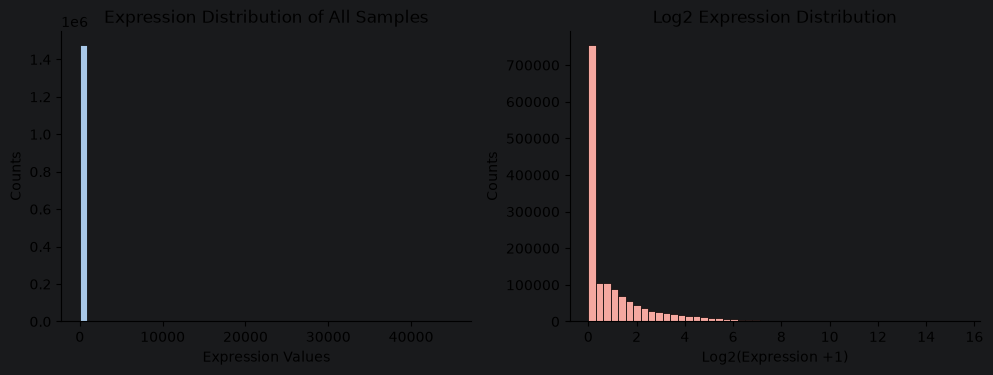

In [4]:
#-------distribution plot------
all_values = expr_df.values.flatten()
all_values = all_values[~np.isnan(all_values)]

plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.hist(all_values, bins=50, color=nature_colors["R"], edgecolor="black", linewidth=0.5)
plt.xlabel("Expression Values")
plt.ylabel("Counts")
plt.title("Expression Distribution of All Samples")

# 只保留左边和下边的边框，颜色改为黑色
ax = plt.gca()
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplot(1, 2, 2)
plt.hist(np.log2(all_values + 1), bins=50, color=nature_colors["CO"], edgecolor="black", linewidth=0.5)
plt.xlabel("Log2(Expression +1)")
plt.ylabel("Counts")
plt.title("Log2 Expression Distribution")
# 只保留左边和下边的边框，颜色改为黑色
ax = plt.gca()
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("./my_transcriptome_data/expression_distribution.png", dpi = 600, transparent = True)
plt.show()

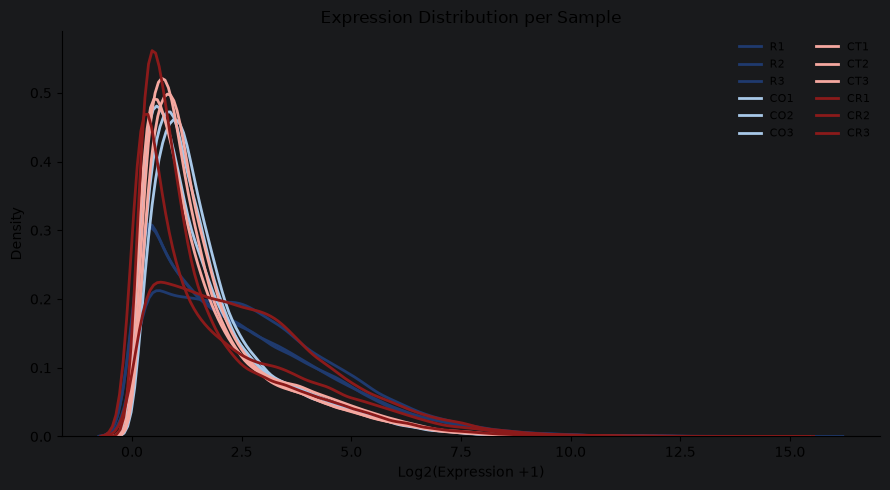

In [17]:
#------Distribution curve of each sample------

# color for each sample
group_palette = {
    'R':  '#1F3A6E',
    'CO': '#A8C8E8',
    'CT': '#F5A8A0',
    'CR': '#8B1A1A'
}

plt.figure(figsize=(9,5))
ax = plt.gca()

for col in expr_cols:
    group = col.rstrip("123") #remove 123 in sample name
    color = group_palette[group]

    values = expr_df[col]
    values = values[values > 0]

    sns.kdeplot(
        np.log2(values+1),
        label = col,
        color = color,
        linewidth = 2,
    )

ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Log2(Expression +1)")
plt.ylabel("Density")
plt.title("Expression Distribution per Sample")
plt.legend(fontsize=8, ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("./my_transcriptome_data/expression_density.png", dpi = 600, transparent = True)
plt.show()


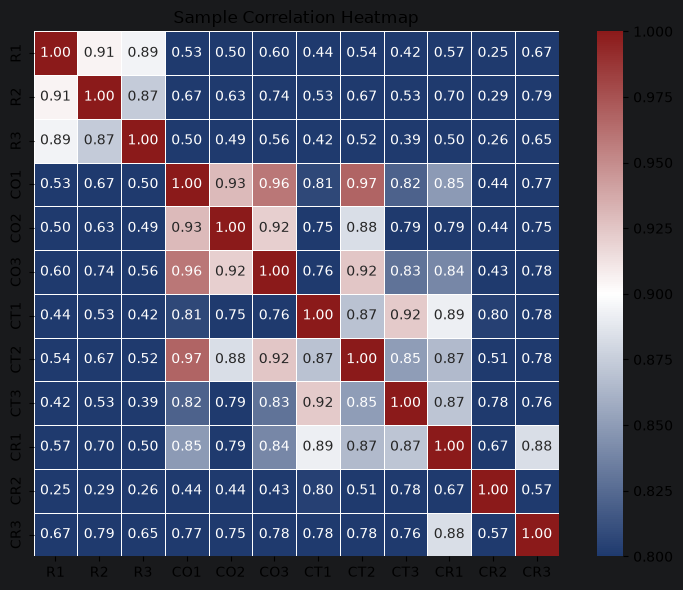

In [6]:
from matplotlib.colors import LinearSegmentedColormap

# ------define color------
nature_cmap = LinearSegmentedColormap.from_list('nature_corr',['#1F3A6E', '#FFFFFF', '#8B1A1A'])

# ------correlation heatmap------
corr = expr_df.corr()

plt.figure(figsize=(8,6))
ax = plt.gca()

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap=nature_cmap,
            vmin=0.8, vmax=1.0,
            linewidths=0.5,
            square=True,
            ax=ax
)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title("Sample Correlation Heatmap")
plt.tight_layout()
plt.savefig("./my_transcriptome_data/sample_correlation_heatmap.png", dpi = 600, transparent = True)
plt.show()


In [7]:
# Group comparison
# Reshape from wide format to long format
long_df = df[["gene_id"] + expr_cols].melt(
    id_vars="gene_id",
    value_vars=expr_cols,
    var_name="sample",
    value_name="expression"
)

# Derive group labels from sample names (strip trailing numbers)
long_df["condition"] = long_df["sample"].str.replace(r"\d+$", "", regex=True)

#log2
long_df["log2_expression"] = np.log2(long_df["expression"] + 1)

print("The shape of form after being transformed:", long_df.shape)
print("\nThe first five lines:")
display(long_df.head(5))
print("\nGroup confirmation: ", long_df["condition"].unique())




The shape of form after being transformed: (1478424, 5)

The first five lines:


,gene_id,sample,expression,condition,log2_expression
0,Cluster-14358.59966,R1,0.00,R,0.000000
1,Cluster-1252.0,R1,0.00,R,0.000000
2,Cluster-32411.0,R1,732.51,R,9.518673
3,Cluster-14358.55088,R1,0.00,R,0.000000
4,Cluster-18277.0,R1,0.00,R,0.000000



Group confirmation:  <StringArray>
['R', 'CO', 'CT', 'CR']
Length: 4, dtype: str


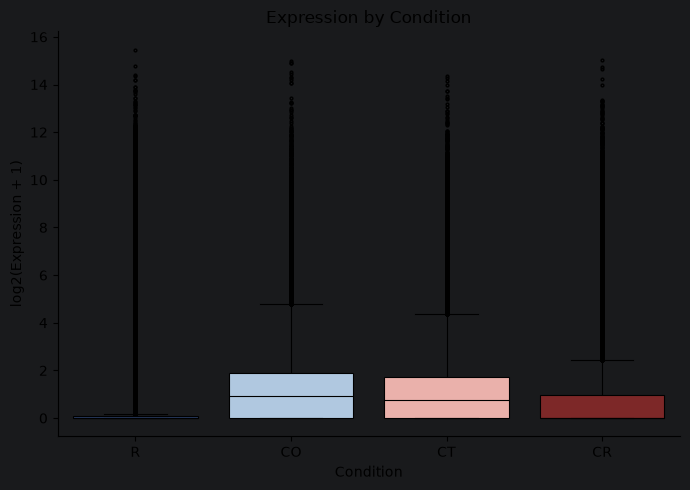

In [16]:
# ------grouped boxplot------
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=long_df,
            x="condition",
            y="log2_expression",
            order = ["R", "CO", "CT", "CR"],
            hue = "condition",
            palette = {'R':  '#1F3A6E',
                       'CO': '#A8C8E8',
                       'CT': '#F5A8A0',
                       'CR': '#8B1A1A'},
            legend=False,
            linecolor="black",
            linewidth=0.8,
            flierprops={"marker": "o",
                        "markersize": 2,
                        "markerfacecolor": "none",
                        "markeredgecolor": "black"},
            ax=ax
            )
ax.spines["bottom"].set_color('black')
ax.spines["left"].set_color('black')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Condition")
ax.set_ylabel("log2(Expression + 1)")
ax.set_title("Expression by Condition")
plt.tight_layout()
plt.savefig("./my_transcriptome_data/expression_by_condition.png", dpi = 600, transparent = True)
plt.show()